# AR Identifier Performance Metrics/Statistics

Notebook to identify performance of the AR clustering code.

Jimmy Butler, August 2024

In [1]:
import os
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Comparisons with Jonathan's Catalog

In [185]:
scratch_path = '/scratch/users/butlerj/extreme_antarctic_ars/datarrays/'
catalog_path = '/accounts/grad/butlerj/extreme_antarctic_ARs/data/ar_catalogs/'
identifier_files = sorted(os.listdir(scratch_path))
jonathans_files = sorted(os.listdir(catalog_path))

diffs = np.zeros(len(identifier_files))

# compute the pixel-by-pixel difference between the catalog and the identifier
for i in range(len(identifier_files)):
    
    identifier_dat = xr.open_dataset(scratch_path + identifier_files[i])
    catalog_dat = xr.open_dataset(catalog_path + jonathans_files[i])
    catalog_dat = catalog_dat.sel(lat=slice(-86, -39))
    id_ar_pts = identifier_dat.cluster != 0
    cat_ar_pts = catalog_dat.ar_binary_tag != 0
    
    diffs[i] = int((id_ar_pts != cat_ar_pts).to_numpy().sum())
    
num_diffs = int(sum(diffs))
print(f'Pixel Differences with Jonathan\'s Catalog: {num_diffs}')

Pixel Differences with Jonathan's Catalog: 0


In [171]:
scratch_path = '/scratch/users/butlerj/extreme_antarctic_ars/datarrays/'
catalog_path = '/accounts/grad/butlerj/extreme_antarctic_ARs/data/ar_catalogs/'
identifier_files = sorted(os.listdir(scratch_path))
jonathans_files = sorted(os.listdir(catalog_path))

diffs = np.zeros(len(identifier_files))
num_px = np.zeros(len(identifier_files))

# compute the pixel-by-pixel difference between the catalog and the identifier
for i in range(len(identifier_files)):
    
    identifier_dat = xr.open_dataset(scratch_path + identifier_files[i])
    no_noise = identifier_dat.where(identifier_dat.cluster != -21007, 0)
    catalog_dat = xr.open_dataset(catalog_path + jonathans_files[i])
    catalog_dat = catalog_dat.sel(lat=slice(-86, -39))
    id_ar_pts = no_noise.cluster != 0
    cat_ar_pts = catalog_dat.ar_binary_tag != 0
    
    diffs[i] = int((id_ar_pts != cat_ar_pts).to_numpy().sum())
    num_px[i] = int(cat_ar_pts.sum().to_numpy())

Text(0, 0.5, '% Difference')

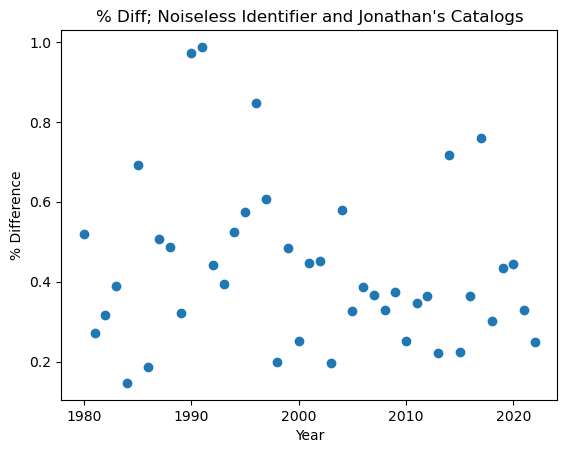

In [183]:
percent_diffs = diffs/num_px*100
years = np.arange(1980, 2023)

plt.scatter(x=years, y=percent_diffs)
plt.title('% Diff; Noiseless Identifier and Jonathan\'s Catalogs')
plt.xlabel('Year')
plt.ylabel('% Difference')

### Storm Counts

In [147]:
scratch_path = '/scratch/users/butlerj/extreme_antarctic_ars/dataframes/'
identifier_dfs = sorted(os.listdir(scratch_path))

storm_cts = np.zeros(len(identifier_dfs))
years = np.zeros(len(identifier_dfs))

for i in range(len(identifier_dfs)):
    
    cur_df = pd.read_csv(scratch_path + identifier_dfs[i])
    # subtract one to exclude noise clusters
    storm_cts[i] = len(cur_df.cluster.value_counts().index) - 1
    years[i] = int(cur_df.time.loc[0][0:4])

Text(0.5, 1.0, 'Number of Individual Storms')

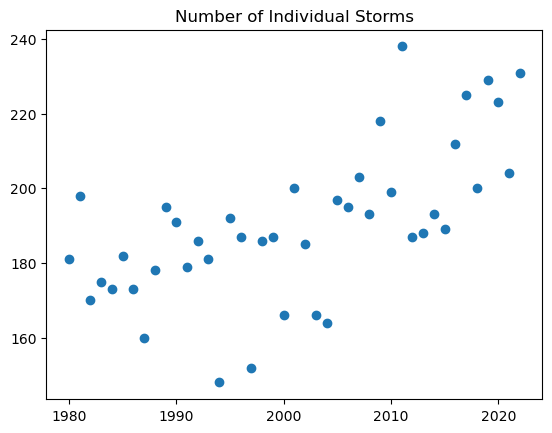

In [146]:
plt.scatter(x = years, y= storm_cts)
plt.title('Number of Individual Storms')

In [203]:
scratch_path = '/scratch/users/butlerj/extreme_antarctic_ars/dataframes/'
identifier_dfs = sorted(os.listdir(scratch_path))

storm_cts = np.zeros(len(identifier_dfs))
years = np.zeros(len(identifier_dfs))

for i in range(len(identifier_dfs)):
    
    cur_df = pd.read_csv(scratch_path + identifier_dfs[i])
    # subtract one to exclude noise clusters
    storm_cts[i] = cur_df.groupby('cluster').filter(lambda subdf: cur_df.is_landfalling.any()).shape[0]
    years[i] = int(cur_df.time.loc[0][0:4])

Text(0.5, 1.0, 'Number of Landfalling Storms')

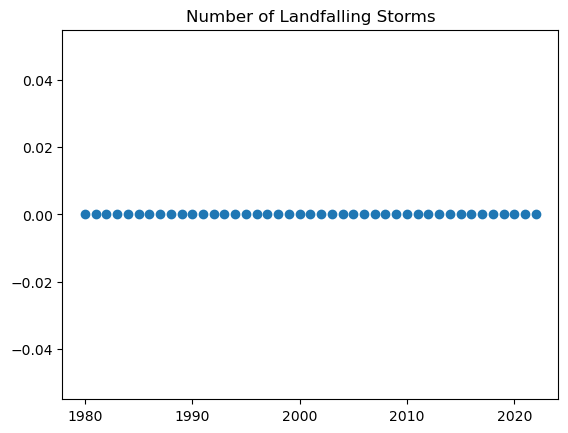

In [204]:
plt.scatter(x = years, y= storm_cts)
plt.title('Number of Landfalling Storms')

In [209]:
from pathlib import Path
curwd = os.getcwd()
mask_path = str(Path(curwd).parents[0]) + '/data/antarctic_masks/AIS_Full_basins_Zwally_MERRA2grid_new.nc'
full_ais_mask = xr.open_dataset(mask_path).Zwallybasins > 0
ais_mask = full_ais_mask.sel(lat=slice(-86, -39))

In [211]:
ais_mask_lats = ais_mask.lat[np.where(ais_mask.to_numpy())[0]].to_numpy()
ais_mask_lons = ais_mask.lon[np.where(ais_mask.to_numpy())[1]].to_numpy()
ais_pts = set(zip(ais_mask_lats, ais_mask_lons))

In [213]:
def is_landfalling(row):
    lats = np.array(np.degrees(row.lats))
    lons = np.array(np.degrees(row.lons))

    storm_pts = set(zip(lats, lons))

    return(bool(storm_pts & ais_pts))